In [20]:
import yfinance as yf

# Download historical stock price data
data = yf.download('AAPL', start='2010-01-01', end='2021-12-31')

# Save to CSV file
data.to_csv("AAPL_stock_data.csv")

print("CSV file saved successfully!")

[*********************100%***********************]  1 of 1 completed

CSV file saved successfully!


In [21]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.412383,6.427064,6.363543,6.395004,493729600
2010-01-05,6.423469,6.459724,6.389610,6.430061,601904800
2010-01-06,6.321297,6.448940,6.314705,6.423471,552160000
2010-01-07,6.309610,6.352158,6.263767,6.344667,477131200
2010-01-08,6.351558,6.352158,6.264067,6.301220,447610800


In [22]:
data.info

<bound method DataFrame.info of Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2010-01-04    6.412383    6.427064    6.363543    6.395004  493729600
2010-01-05    6.423469    6.459724    6.389610    6.430061  601904800
2010-01-06    6.321297    6.448940    6.314705    6.423471  552160000
2010-01-07    6.309610    6.352158    6.263767    6.344667  477131200
2010-01-08    6.351558    6.352158    6.264067    6.301220  447610800
...                ...         ...         ...         ...        ...
2021-12-23  172.496674  173.054447  171.508356  172.075909   68356600
2021-12-27  176.459717  176.547782  173.269689  173.289249   74919600
2021-12-28  175.442032  177.438257  174.698349  176.293370   79144300
2021-12-29  175.530136  176.753309  174.316744  175.481206   62348900
2021-12-30  174.375443  176.694587  174.267803  175.618190

In [23]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,3020.000000,3020.000000,3020.000000,3020.000000,3.020000e+03
mean,40.065623,40.462379,39.631996,40.043068,2.703273e+08
std,37.698873,38.107650,37.240208,37.662443,2.259580e+08
min,5.754393,5.872749,5.700462,5.763984,4.100000e+07
25%,15.880877,16.005940,15.650299,15.790924,1.096879e+08
50%,25.540514,25.749491,25.244709,25.512728,1.842352e+08
75%,45.631120,46.044573,45.275778,45.667211,3.709670e+08
max,176.459717,178.221071,174.698349,177.232738,1.880998e+09


In [24]:
data.shape

(3020, 5)

In [25]:
data.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [26]:
import numpy as np   
from sklearn.preprocessing import MinMaxScaler

# Use the 'Close' price for predictions
close_prices = data['Close'].values
close_prices = close_prices.reshape(-1, 1)

# Normalizing the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

# Creating dataset with X_train and y_train
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]

# Function to create dataset
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        a = data[i:(i + time_step), 0]
        X.append(a)
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Specify time step and create training data
time_step = 60
X_train, y_train = create_dataset(train_data, time_step)

# Reshaping X_train for LSTM input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

In [27]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [28]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

# Create the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1)) # Predicting the 'Close' price

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit the model on training data
model.fit(X_train, y_train, batch_size=32, epochs=10, verbose=1)

C:\Users\Shikhar Khanna\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - loss: 8.1391e-04
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 1.4667e-04
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 1.1601e-04
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 9.7710e-05
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 9.3406e-05
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 8.3794e-05
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - loss: 7.7086e-05
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 6.8345e-05
Epoch 9/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 6.7299e-05
Epoch 10/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 7.7675e-05


In [29]:
test_data = scaled_data[train_size - time_step:]
X_test, y_test = create_dataset(test_data, time_step)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step


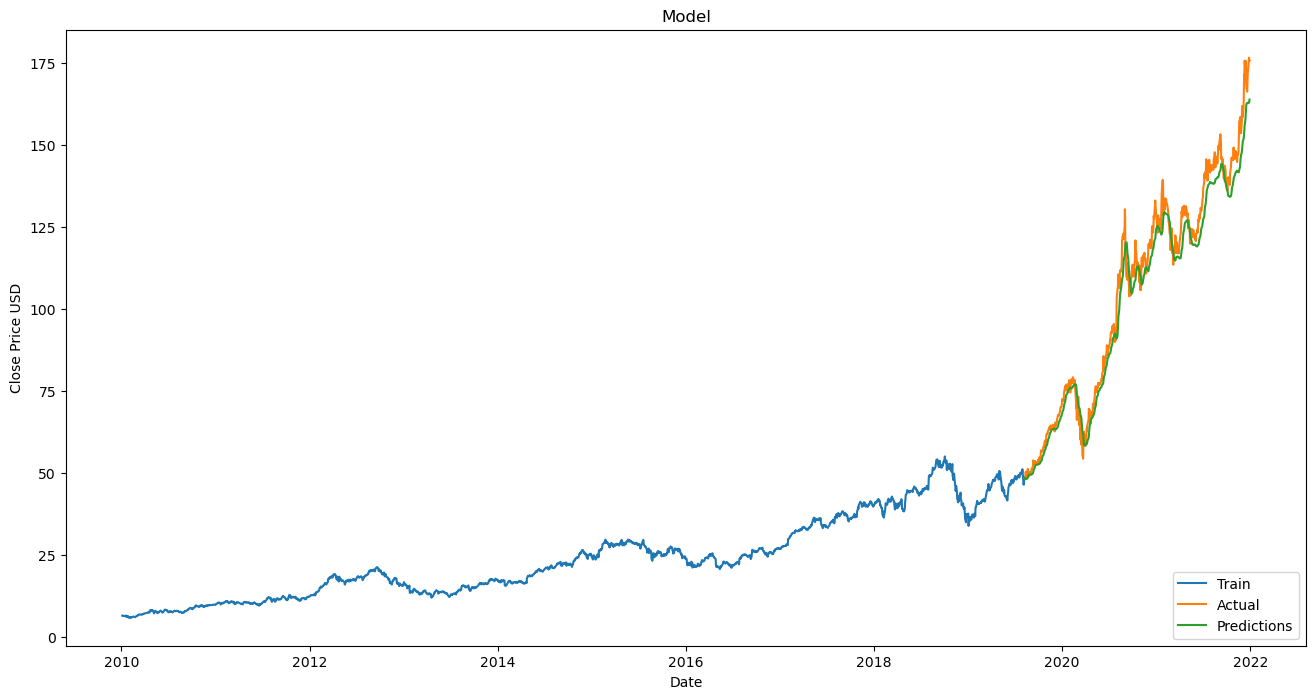

In [36]:
train = data[['Close']][:train_size]

# Create valid from correct starting point
valid = data[['Close']][train_size:].copy()

# Trim valid to match predictions length
valid = valid.iloc[:len(predictions)]

# Add predictions safely
valid['Predictions'] = predictions.flatten()

# Plot
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date')
plt.ylabel('Close Price USD')

plt.plot(train['Close'])
plt.plot(valid['Close'])
plt.plot(valid['Predictions'])

plt.legend(['Train','Actual','Predictions'], loc='lower right')
plt.show()

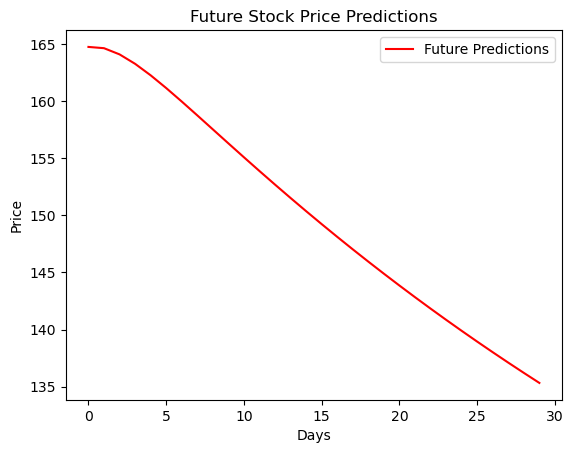

In [37]:
def make_future_predictions(model, data, time_step, n_predictions):
    predictions = []

    # take last sequence
    last_sequence = data[-time_step:]
    last_sequence = last_sequence.flatten()

    for _ in range(n_predictions):

        # reshape for LSTM input
        last_sequence_reshaped = last_sequence.reshape(1, time_step, 1)

        # predict next value
        next_prediction = model.predict(last_sequence_reshaped, verbose=0)

        # store prediction
        predictions.append(next_prediction[0, 0])

        # update sequence (remove first, add new prediction)
        last_sequence = np.append(last_sequence[1:], next_prediction[0, 0])

    return np.array(predictions)
# Example: Predicting next 30 days
future_predictions = make_future_predictions(model, scaled_data, time_step, 30)
future_predictions_inverse = scaler.inverse_transform(future_predictions.reshape(-1, 1))

# Visualizing future predictions
plt.plot(future_predictions_inverse, color='red', label='Future Predictions')
plt.title('Future Stock Price Predictions')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend() 
plt.show()